# NPZ Gaze Visualization Viewer

This notebook visualizes SparseGaze per-sequence prediction `.npz` files with the same output types used by CSV gaze visualization:

- Scene-frame gaze rays
- reference-frame scanpath overlay
- clean reference-frame scanpath
- per-frame RGB overlays
- overlay video

Important: prediction `.npz` files store `pred_xyz` / `gt_xyz` as **Scene-frame unit gaze directions**. They do not store depth-defined gaze points. This notebook uses extracted `gaze_samples.csv` to recover the gaze/head origin and either:

- `gt_depth`: place the predicted ray endpoint at the GT ADT gaze depth for that frame;
- `fixed`: place every endpoint at a fixed metric ray length.

In [1]:
from pathlib import Path
import sys

REPO_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(REPO_ROOT))
sys.path.insert(0, str(REPO_ROOT / "src"))

from IPython.display import Image, Video, display

from adt_sandbox.config import load_dotenv
from adt_sandbox.providers import create_adt_providers
from visualization.npz_gaze_outputs import (
    generate_npz_gaze_visualizations,
    load_prediction_npz,
    prediction_metadata_table,
)
from visualization.prediction_eval import discover_prediction_runs

load_dotenv(REPO_ROOT / ".env")

## Configuration

Set `EVAL_ROOT` to a model eval directory that contains `sequence_predictions/*.npz`. The `sparsegaze_cpf_rotation_only` aggregate directory may not contain per-sequence NPZ files unless that eval was run with sequence prediction saving enabled.

In [2]:
REPORTS_DIR = Path("/mnt/d/SparseGaze/ADT-Gaze-structured")
EVAL_ROOT = Path("/home/liumu/Github_Projects/SparseGaze/outputs/eval/adt/sparsegaze")
OUTPUT_ROOT = REPO_ROOT / "outputs" / "figures" / "gaze_npz"

runs = discover_prediction_runs(EVAL_ROOT)
print(f"eval_root={EVAL_ROOT}")
print(f"prediction files={len(runs)}")
display(runs.head(80))

eval_root=/home/liumu/Github_Projects/SparseGaze/outputs/eval/adt/sparsegaze
prediction files=150


,model,eval_kind,sequence,target_hz,phase,path
0,sparsegaze,oracle,Apartment_release_decoration_skeleton_seq133_M...,10,0,/home/liumu/Github_Projects/SparseGaze/outputs...
1,sparsegaze,oracle,Apartment_release_decoration_skeleton_seq133_M...,15,0,/home/liumu/Github_Projects/SparseGaze/outputs...
2,sparsegaze,oracle,Apartment_release_decoration_skeleton_seq133_M...,6,0,/home/liumu/Github_Projects/SparseGaze/outputs...
3,sparsegaze,oracle,Apartment_release_decoration_skeleton_seq134_M...,10,0,/home/liumu/Github_Projects/SparseGaze/outputs...
4,sparsegaze,oracle,Apartment_release_decoration_skeleton_seq134_M...,15,0,/home/liumu/Github_Projects/SparseGaze/outputs...
...,...,...,...,...,...,...
75,sparsegaze,rollout_gt,Apartment_release_meal_skeleton_seq135_M1292,10,0,/home/liumu/Github_Projects/SparseGaze/outputs...
76,sparsegaze,rollout_gt,Apartment_release_meal_skeleton_seq135_M1292,15,0,/home/liumu/Github_Projects/SparseGaze/outputs...
77,sparsegaze,rollout_gt,Apartment_release_meal_skeleton_seq135_M1292,6,0,/home/liumu/Github_Projects/SparseGaze/outputs...
78,sparsegaze,rollout_gt,Apartment_release_work_skeleton_seq107_M1292,10,0,/home/liumu/Github_Projects/SparseGaze/outputs...


In [3]:
# Selection. Edit these after inspecting `runs`.
SELECT_EVAL_KIND = runs["eval_kind"].iloc[0] if not runs.empty else "rollout"
SELECT_SEQUENCE = runs["sequence"].iloc[0] if not runs.empty else ""
SELECT_HZ = int(runs["target_hz"].iloc[0]) if not runs.empty else 10
SELECT_PHASE = int(runs["phase"].iloc[0]) if not runs.empty else 0

# Track can be "pred" or "gt". Run both tracks in separate cells if needed.
TRACK = "pred"
DEPTH_MODE = "gt_depth"  # "gt_depth" or "fixed"
FIXED_DEPTH_M = 2.0
START_ROW = 0
END_ROW = 120
STRIDE = 10

selected = runs[
    (runs["eval_kind"] == SELECT_EVAL_KIND)
    & (runs["sequence"] == SELECT_SEQUENCE)
    & (runs["target_hz"] == SELECT_HZ)
    & (runs["phase"] == SELECT_PHASE)
]
if selected.empty:
    raise ValueError("No prediction NPZ matches the current selection.")
NPZ_PATH = Path(selected.iloc[0]["path"])
print(NPZ_PATH)
display(prediction_metadata_table(NPZ_PATH))

/home/liumu/Github_Projects/SparseGaze/outputs/eval/adt/sparsegaze/test/oracle/sequence_predictions/Apartment_release_decoration_skeleton_seq133_M1292/hz10_phase0.npz


,sequence,target_hz,phase,n_frames,n_eval,n_anchor
0,Apartment_release_decoration_skeleton_seq133_M...,10,0,2736,1814,912


## Generate CSV-Style Visualizations from NPZ

This opens the ADT provider only for the selected sequence/window. `skeleton_flag=False` is intentional: these gaze visualizations only need RGB frames, poses, and calibration.

In [4]:
prediction = load_prediction_npz(NPZ_PATH)
providers = create_adt_providers(prediction["sequence"], skeleton_flag=False)

result = generate_npz_gaze_visualizations(
    gt_provider=providers.gt_provider,
    npz_path=NPZ_PATH,
    reports_dir=REPORTS_DIR,
    output_root=OUTPUT_ROOT,
    track=TRACK,
    start_row=START_ROW,
    end_row=END_ROW,
    stride=STRIDE,
    depth_mode=DEPTH_MODE,
    fixed_depth_m=FIXED_DEPTH_M,
    run_name=f"{SELECT_EVAL_KIND}_hz{SELECT_HZ}_phase{SELECT_PHASE}_{TRACK}_{DEPTH_MODE}_{START_ROW}_{END_ROW}_s{STRIDE}",
)
result

Loaded #closed loop trajectory poses records: 2738
Loaded #EyeGazes: 3483


[MpsDataPathsProvider][WARNING]: Hand tracking folder (/mnt/d/Pose2Gaze-ADT/Apartment_release_decoration_skeleton_seq133_M1292/mps/hand_tracking) does not exist in MPS root folder, not loading hand tracking results.
[ProgressLogger][INFO]: 2026-06-08 10:12:42: Opening /mnt/d/Pose2Gaze-ADT/Apartment_release_decoration_skeleton_seq133_M1292/video.vrs...
[MultiRecordFileReader][DEBUG]: Opened file '/mnt/d/Pose2Gaze-ADT/Apartment_release_decoration_skeleton_seq133_M1292/video.vrs' and assigned to reader #0
[VrsDataProvider][INFO]: streamId 211-1/camera-et activated
[VrsDataProvider][INFO]: streamId 214-1/camera-rgb activated
[VrsDataProvider][INFO]: streamId 247-1/baro0 activated
[VrsDataProvider][INFO]: Utc stream found: 285-1
[VrsDataProvider][INFO]: Timecode stream found: 285-2
[VrsDataProvider][INFO]: streamId 1201-1/camera-slam-left activated
[VrsDataProvider][INFO]: streamId 1201-2/camera-slam-right activated
[VrsDataProvider][INFO]: streamId 1202-1/imu-right activated
[VrsDataProvid

{'output_dir': PosixPath('/home/liumu/Github_Projects/adt_dataset_sandbox/outputs/figures/gaze_npz/Apartment_release_decoration_skeleton_seq133_M1292/npz_visualizations/oracle_hz10_phase0_pred_gt_depth_0_120_s10'),
 'sequence': 'Apartment_release_decoration_skeleton_seq133_M1292',
 'track': 'pred',
 'depth_mode': 'gt_depth',
 'window_samples': 120,
 'viz_samples': 13}

## Display Generated Figures

The filenames mirror the CSV visualizer outputs. `pred_*` and `gt_*` outputs can be generated separately by changing `TRACK` and rerunning the previous cell.

/home/liumu/Github_Projects/adt_dataset_sandbox/outputs/figures/gaze_npz/Apartment_release_decoration_skeleton_seq133_M1292/npz_visualizations/oracle_hz10_phase0_pred_gt_depth_0_120_s10
/home/liumu/Github_Projects/adt_dataset_sandbox/outputs/figures/gaze_npz/Apartment_release_decoration_skeleton_seq133_M1292/npz_visualizations/oracle_hz10_phase0_pred_gt_depth_0_120_s10/pred_scene_rays.png


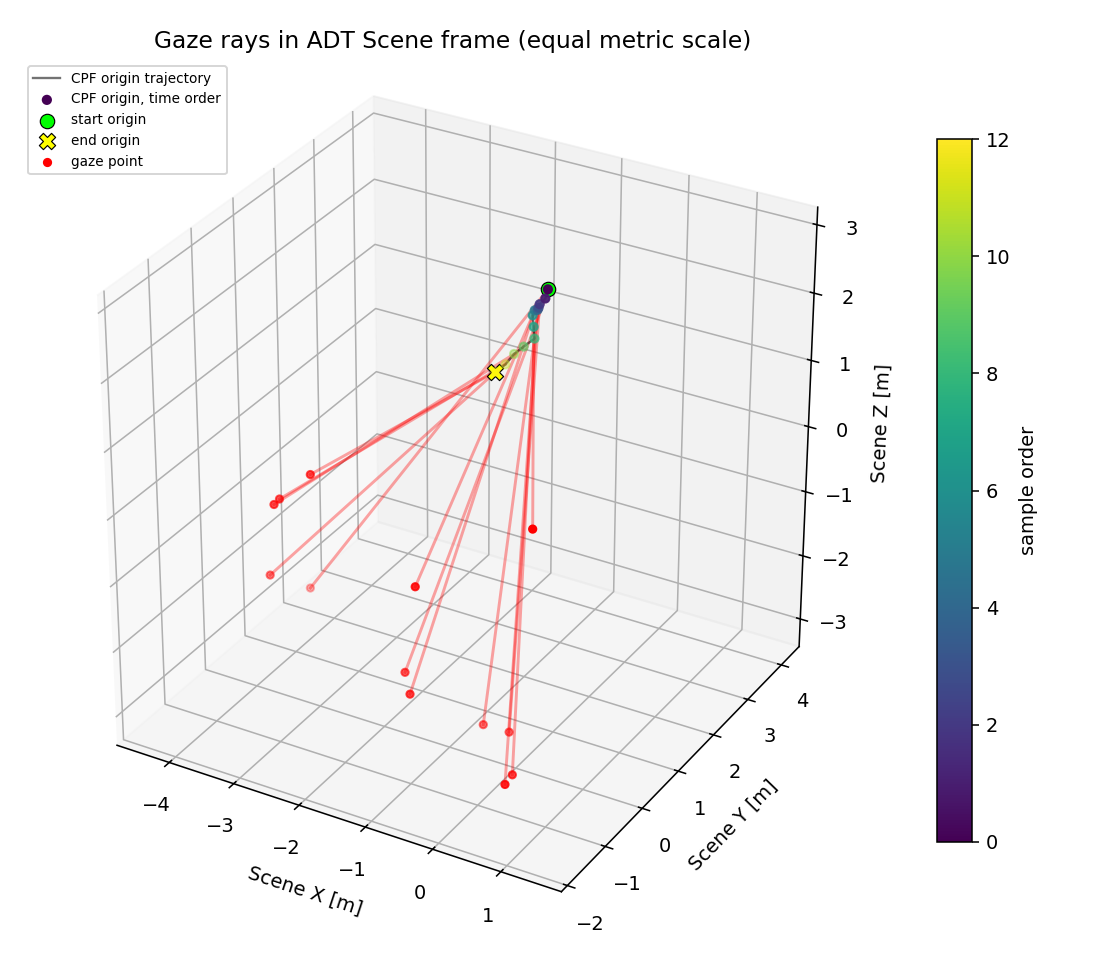

/home/liumu/Github_Projects/adt_dataset_sandbox/outputs/figures/gaze_npz/Apartment_release_decoration_skeleton_seq133_M1292/npz_visualizations/oracle_hz10_phase0_pred_gt_depth_0_120_s10/pred_reference_frame_scanpath_overlay.png


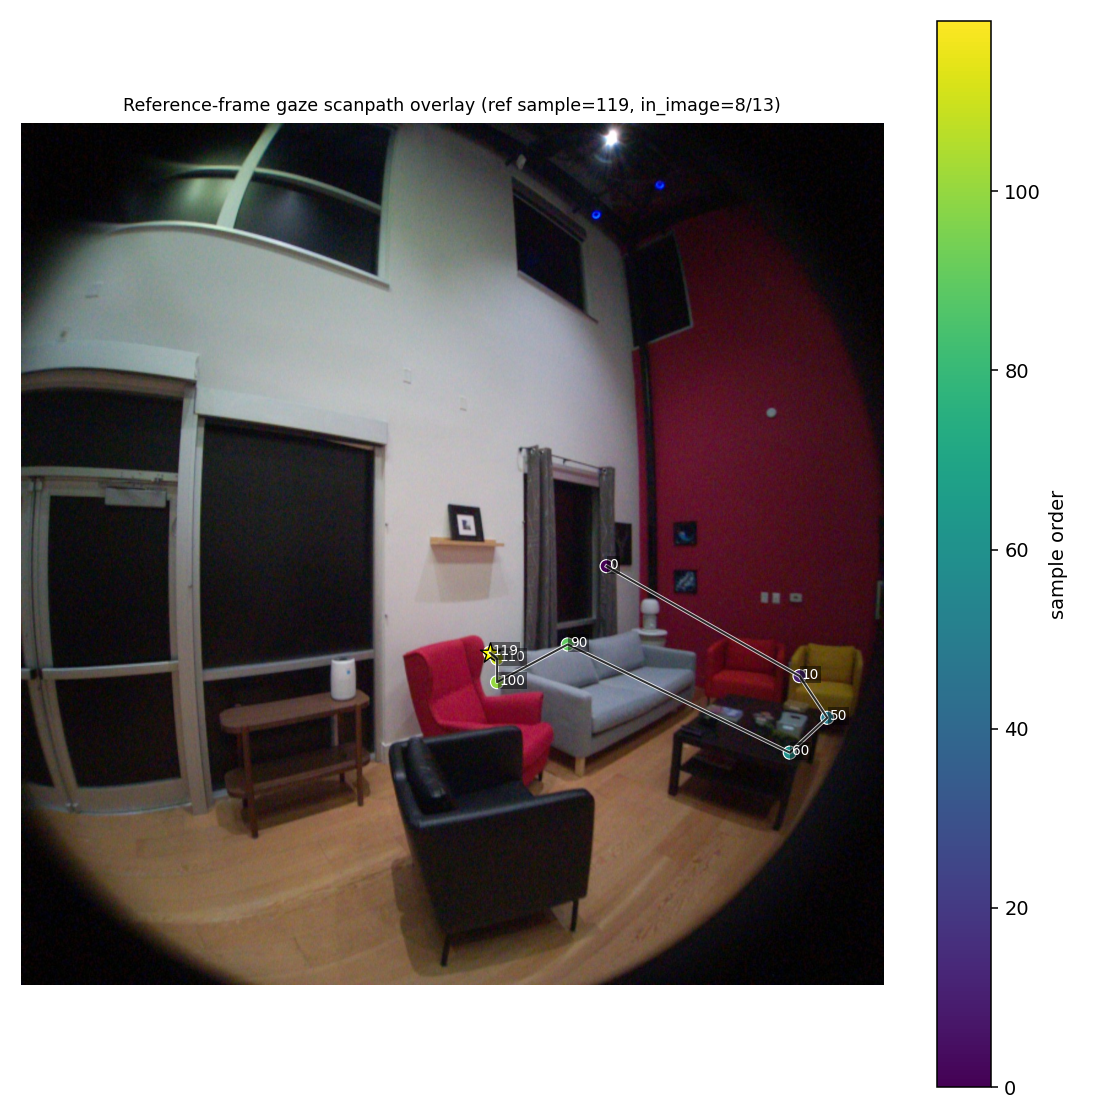

/home/liumu/Github_Projects/adt_dataset_sandbox/outputs/figures/gaze_npz/Apartment_release_decoration_skeleton_seq133_M1292/npz_visualizations/oracle_hz10_phase0_pred_gt_depth_0_120_s10/pred_reference_frame_scanpath_clean.png


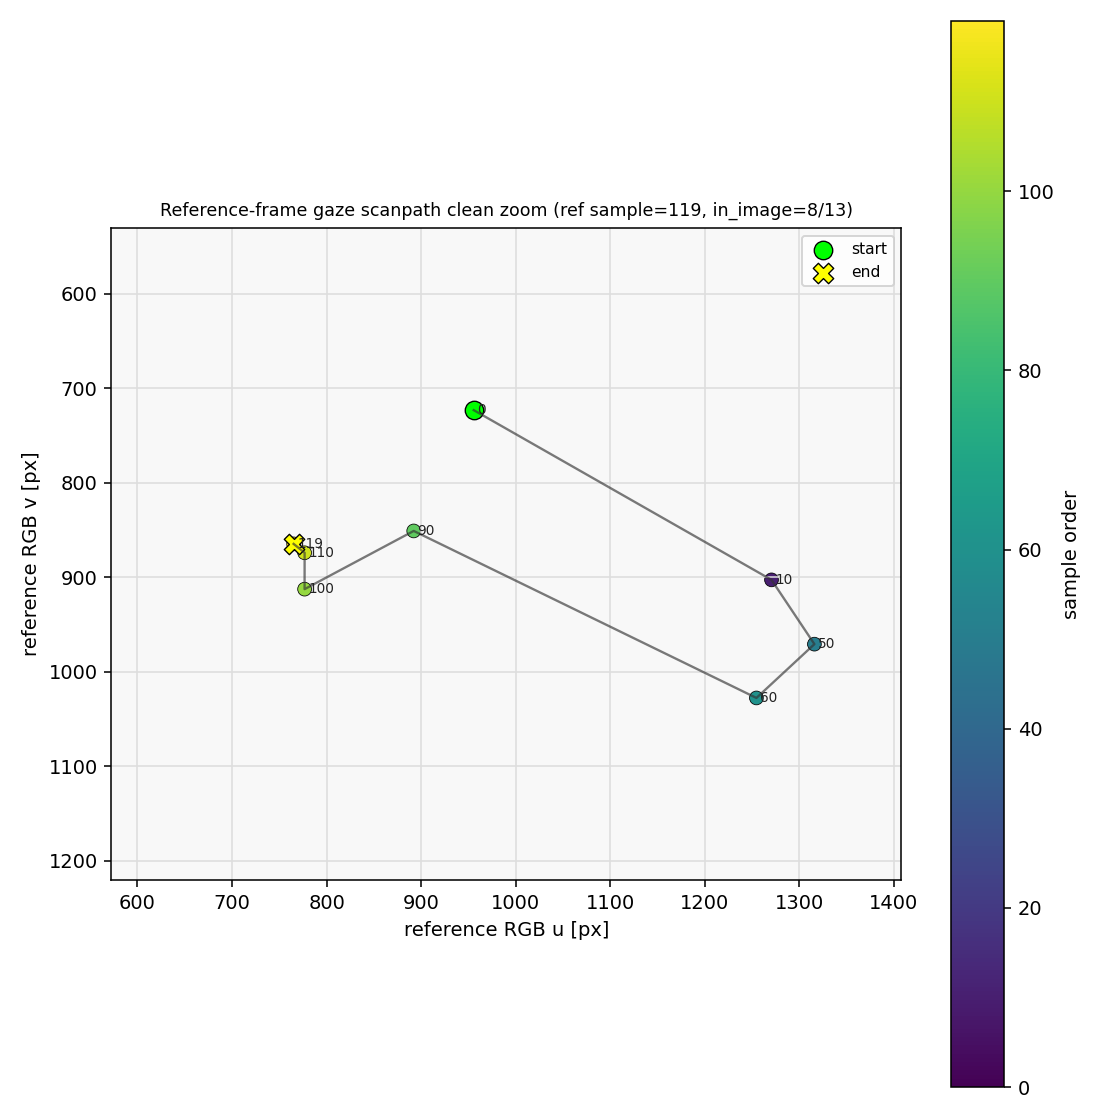

In [5]:
out_dir = Path(result["output_dir"])
print(out_dir)

for name in [
    f"{TRACK}_scene_rays.png",
    f"{TRACK}_reference_frame_scanpath_overlay.png",
    f"{TRACK}_reference_frame_scanpath_clean.png",
]:
    path = out_dir / name
    print(path)
    if path.exists():
        display(Image(filename=str(path)))

In [6]:
video_path = out_dir / f"{TRACK}_overlay_video.mp4"
print(video_path)
if video_path.exists():
    display(Video(str(video_path), embed=True))

/home/liumu/Github_Projects/adt_dataset_sandbox/outputs/figures/gaze_npz/Apartment_release_decoration_skeleton_seq133_M1292/npz_visualizations/oracle_hz10_phase0_pred_gt_depth_0_120_s10/pred_overlay_video.mp4


## Compare Pred and GT Tracks

To compare predicted and GT visualization outputs, rerun the generation cell twice:

1. `TRACK = "gt"`
2. `TRACK = "pred"`

Both are saved under the same `OUTPUT_ROOT`, with the track name included in filenames and run names.

The current adapter uses Scene-frame directions from the NPZ. It does not convert them back to CPF yaw/pitch. For CPF-space residual analysis, use `Experiments/visualization & Analysis/ADT/notebooks/08_prediction_gaze_evaluation_viewer.ipynb`.